# Computer Use Agents — From Scratch to the Frontier

You've built training loops, RAG pipelines, and agent harnesses. Today we build the
thing that lets a model *drive a computer the way a person does*: look at the screen,
decide where to click, click, look again.

**The arc of this notebook is deliberately a failure story.**

1. **Stage 1** — Put a real browser in this Colab and take a screenshot. (Perception)
2. **Stage 2** — Hand-roll the loop: screenshot → VLM → parse an action → execute → repeat.
   Watch it miss clicks.
3. **Stage 3** — Diagnose *why* it misses. This is the **grounding problem**, and it's the
   single thread that runs through the entire history of this field.
4. **Stage 4** — Swap our hand-rolled loop for Claude's **native computer-use tool**
   (`computer_20251124`). Same browser, same task. See what changes.
5. **Stage 5** — Situate what we built against the frontier: OSWorld, open models
   (UI-TARS, Qwen-VL), and the "is it even a GUI?" debate (CoAct, CLI-as-computer-use).

By the end you'll understand not just *how* to call a computer-use API, but *why the API
is shaped the way it is* — because you'll have felt the pain it removes.

> **Runtime:** CPU is fine for Stages 1–3. Stage 4 calls a model API. Everything installs
> in one cell and runs on a free Colab instance.

## Stage 0 — Why a browser, not a desktop?

Real computer-use systems (Anthropic's reference implementation, Cua, OSWorld) run a full
Linux desktop inside a container: an X11 virtual display (Xvfb), a window manager (Mutter),
a panel (Tint2), and real apps like Firefox and LibreOffice. The model sees screenshots of
*that* and controls a real mouse and keyboard.

We're not doing that here, for one reason: **it's a setup landmine in Colab and it teaches
you nothing extra.** A headless browser gives us everything that matters for the lesson —
real rendered pixels, real screenshots, real coordinates, and clicks that either land on the
target or don't. The grounding problem is *identical* whether the pixels come from Firefox-in-Xvfb
or headless Chromium. We keep the environment trivial so the *agent loop* stays in focus.

We'll flag exactly where the real thing differs as we go.

---
# Stage 1 — Perception: get a real screen into Python

First: a browser we can screenshot and control. Playwright drives a real Chromium; we run it
headless. One install cell.

In [1]:
# Install Playwright + a headless Chromium. ~30-60s on first run.
!pip install playwright --quiet
!playwright install chromium --with-deps 2>/dev/null || playwright install chromium
print("Playwright + Chromium ready.")

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.4/47.4 MB 18.7 MB/s eta 0:00:00
Installing dependencies...
Get:1 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ InRelease [3,632 B]
Get:2 https://cli.github.com/packages stable InRelease [3,917 B]
Get:3 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]
Hit:4 http://archive.ubuntu.com/ubuntu jammy InRelease
Get:5 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]
Get:6 https://cloud.r-project.org/bin/linux/ubuntu jammy-cran40/ Packages [99.9 kB]
Get:7 https://r2u.stat.illinois.edu/ubuntu jammy InRelease [6,555 B]
Get:8 https://cli.github.com/packages stable/main amd64 Packages [355 B]
Get:9 http://archive.ubuntu.com/ubuntu jammy-backports InRelease [127 kB]
Get:10 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [4,083 kB]
Get:11 https://ppa.launchpadcontent.net/deadsnakes/ppa/ubuntu jammy InRelease [18.1 kB]
Get:12 http://security.ubuntu.com/ubuntu jammy-security/universe amd

In [3]:
# Colab runs an event loop already, so we use Playwright's SYNC API inside a thread-safe
# wrapper. The helper below hides that detail; treat `Browser` as a simple screen you can
# screenshot, click, and type into.
import nest_asyncio, asyncio
nest_asyncio.apply()

from playwright.async_api import async_playwright
import base64, io
from PIL import Image

class Browser:
    """A minimal 'screen' abstraction: screenshot / click / type / scroll / key.
    Coordinates are in the SAME pixel space as the screenshots we hand to the model."""
    def __init__(self, width=1024, height=768):
        self.width, self.height = width, height
        self._pw = None; self._browser = None; self.page = None

    async def _astart(self, url):
        self._pw = await async_playwright().start()
        self._browser = await self._pw.chromium.launch(args=["--no-sandbox"])
        self.page = await self._browser.new_page(viewport={"width": self.width, "height": self.height})
        await self.page.goto(url, wait_until="networkidle")

    def start(self, url):  asyncio.get_event_loop().run_until_complete(self._astart(url))
    def goto(self, url):   asyncio.get_event_loop().run_until_complete(self.page.goto(url, wait_until="networkidle"))

    async def _ashot(self):
        return await self.page.screenshot()
    def screenshot(self):
        png = asyncio.get_event_loop().run_until_complete(self._ashot())
        return Image.open(io.BytesIO(png))
    def screenshot_b64(self):
        png = asyncio.get_event_loop().run_until_complete(self._ashot())
        return base64.standard_b64encode(png).decode()

    def click(self, x, y):
        asyncio.get_event_loop().run_until_complete(self.page.mouse.click(x, y))
    def type_text(self, text):
        asyncio.get_event_loop().run_until_complete(self.page.keyboard.type(text))
    def press(self, key):
        asyncio.get_event_loop().run_until_complete(self.page.keyboard.press(key))
    def scroll(self, dy):
        asyncio.get_event_loop().run_until_complete(self.page.mouse.wheel(0, dy))
    def close(self):
        if self._browser: asyncio.get_event_loop().run_until_complete(self._browser.close())
        if self._pw: asyncio.get_event_loop().run_until_complete(self._pw.stop())

print("Browser helper defined.")

Browser helper defined.


We need a target site. To keep the class fully reproducible and offline-safe, we'll serve
a **local page we control** — a tiny "expense filing" form. That mirrors the financial-analyst
domain from earlier classes, and because we own the HTML we can measure grounding *exactly*:
we know the true pixel location of every button.

In [4]:
# A self-contained target app: an expense-approval form. Served locally.
EXPENSE_APP = '''
<!doctype html><html><head><meta charset="utf-8"><title>Expense Portal</title>
<style>
  body{font-family:Arial,Helvetica,sans-serif;margin:0;background:#f4f5f7;color:#1a1a2e}
  header{background:#2d2a4a;color:#fff;padding:16px 24px;font-size:20px;font-weight:bold}
  .wrap{max-width:640px;margin:32px auto;background:#fff;border-radius:10px;padding:28px;
        box-shadow:0 2px 10px rgba(0,0,0,.08)}
  label{display:block;margin:14px 0 4px;font-size:13px;font-weight:bold;color:#444}
  input,select{width:100%;padding:10px;font-size:14px;border:1px solid #ccc;border-radius:6px;box-sizing:border-box}
  .row{display:flex;gap:16px}.row>div{flex:1}
  .btns{margin-top:24px;display:flex;gap:12px;justify-content:flex-end}
  button{padding:11px 22px;font-size:14px;border:none;border-radius:6px;cursor:pointer;font-weight:bold}
  #cancel{background:#e6e6ea;color:#333}
  #submit{background:#5b4b8a;color:#fff}
  #status{margin-top:18px;padding:12px;border-radius:6px;font-size:14px;display:none}
  .ok{background:#e4f7ec;color:#1c7a45}
</style></head>
<body>
  <header>Acme Expense Portal</header>
  <div class="wrap">
    <label for="vendor">Vendor</label>
    <input id="vendor" placeholder="e.g. United Airlines">
    <div class="row">
      <div><label for="amount">Amount (USD)</label><input id="amount" placeholder="0.00"></div>
      <div><label for="category">Category</label>
        <select id="category"><option>Travel</option><option>Meals</option>
        <option>Software</option><option>Other</option></select></div>
    </div>
    <label for="memo">Memo</label>
    <input id="memo" placeholder="Business purpose">
    <div class="btns">
      <button id="cancel">Cancel</button>
      <button id="submit">Submit for Approval</button>
    </div>
    <div id="status"></div>
  </div>
  <script>
    document.getElementById("submit").addEventListener("click",()=>{
      const v=document.getElementById("vendor").value,
            a=document.getElementById("amount").value;
      const s=document.getElementById("status");
      s.style.display="block"; s.className="ok";
      s.textContent="✓ Submitted: "+(v||"(no vendor)")+" — $"+(a||"0.00");
    });
  </script>
</body></html>
'''
with open("expense_app.html","w") as f: f.write(EXPENSE_APP)

# Serve it on localhost so Playwright can navigate to a real URL.
import threading, http.server, socketserver, functools, os
os.chdir("/content" if os.path.isdir("/content") else ".")
with open("expense_app.html","w") as f: f.write(EXPENSE_APP)
PORT = 8000
Handler = functools.partial(http.server.SimpleHTTPRequestHandler)
def serve():
    with socketserver.TCPServer(("", PORT), Handler) as httpd:
        httpd.serve_forever()
threading.Thread(target=serve, daemon=True).start()
URL = f"http://localhost:{PORT}/expense_app.html"
print("Serving target app at", URL)

Serving target app at http://localhost:8000/expense_app.html


127.0.0.1 - - [08/Jul/2026 04:57:59] "GET /expense_app.html HTTP/1.1" 200 -


Screenshot size: (1024, 768)


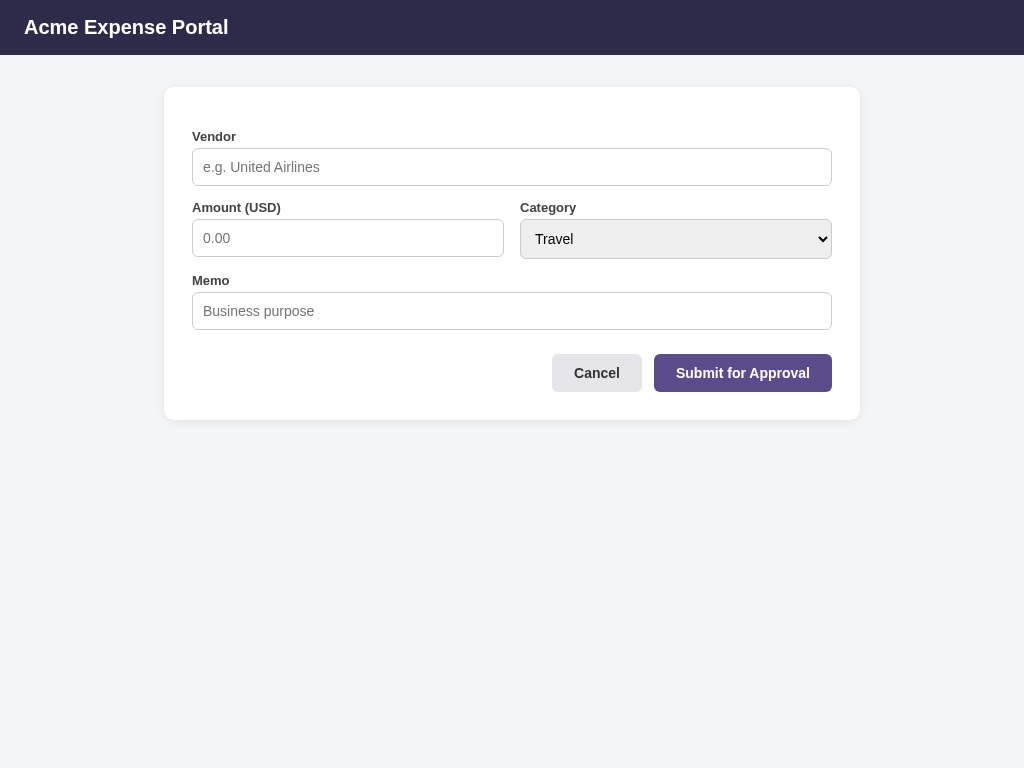

In [5]:
# Take our first screenshot — this is the model's entire window into the world.
b = Browser(width=1024, height=768)
b.start(URL)
shot = b.screenshot()
print("Screenshot size:", shot.size)
shot

That image is *all a computer-use model ever gets*. No DOM, no accessibility tree, no
element IDs — just pixels. (Real systems can optionally add the accessibility tree; the
pure-vision setting is the hard, general case, and the one the frontier has converged on.)

**The task for our agent:** *"File an expense for United Airlines, $450, category Travel,
then submit it."* Trivial for you. Watch what it takes for a model.

---
# Stage 2 — Build the loop by hand (and watch it break)

The pattern every computer-use agent uses — first written down by Dillon Dupont's
**GPT-4V-Act** in October 2023, weeks after GPT-4V shipped:

> **screenshot → understand → decide → act → repeat**

We'll implement exactly that with a general vision model over OpenRouter (matches our stack;
free-tier models work). Crucially, this model was **not** trained to output screen coordinates.
We're asking it to ground purely from the prompt. That's the naive baseline — and the point.

In [6]:
import os, getpass
# OpenRouter key. In class, students paste a free-tier key. Falls back to a mock if absent
# so the notebook still runs end-to-end offline.
OPENROUTER_KEY = "REDACTED-SECRET-REMOVED"
if not OPENROUTER_KEY:
    try:
        OPENROUTER_KEY = getpass.getpass("OpenRouter API key (blank = run in MOCK mode): ").strip()
    except Exception:
        OPENROUTER_KEY = ""
MOCK = (OPENROUTER_KEY == "")
print("MODE:", "MOCK (canned failure trajectory)" if MOCK else "LIVE via OpenRouter")

MODE: LIVE via OpenRouter


In [17]:
import json, requests

VISION_MODEL = "google/gemma-4-31b-it:free"  # any vision model on OpenRouter works

SYSTEM = """You control a computer by looking at screenshots. The screen is 1024x768 pixels.
Return ONE action as strict JSON, nothing else. Schema:
{"action":"click","x":<int>,"y":<int>}  |  {"action":"type","text":"<str>"}
{"action":"key","key":"<str>"}  |  {"action":"scroll","dy":<int>}  |  {"action":"done"}
The origin (0,0) is the TOP-LEFT. x grows right, y grows down."""

def vlm_action(task, b64png, history):
    """Ask the general VLM for the next action, given the current screenshot."""
    if MOCK:
        # Canned trajectory that reproduces the REAL failure mode we see live:
        # plausible-looking but mis-grounded coordinates.
        # True centers (this layout): vendor (512,167), amount (348,238),
        # submit (743,373). The canned clicks are plausible but mis-grounded near-misses.
        canned = [
            {"action":"click","x":512,"y":140,"_note":"aims for vendor, lands ~25px high on the label"},
            {"action":"type","text":"United Airlines"},
            {"action":"click","x":512,"y":238,"_note":"aims for amount, drifts right into the Category box"},
            {"action":"type","text":"450"},
            {"action":"click","x":743,"y":430,"_note":"aims for Submit, lands ~55px below the button"},
            {"action":"done"},
        ]
        return canned[min(len(history), len(canned)-1)]
    msgs = [{"role":"system","content":SYSTEM},
            {"role":"user","content":[
                {"type":"text","text":f"Task: {task}\nActions so far: {json.dumps(history)}\nNext action as JSON:"},
                {"type":"image_url","image_url":{"url":f"data:image/png;base64,{b64png}"}}]}]
    r = requests.post("https://openrouter.ai/api/v1/chat/completions",
        headers={"Authorization":f"Bearer {OPENROUTER_KEY}"},
        json={"model":VISION_MODEL,"messages":msgs,"max_tokens":200,"temperature":0})
    data = r.json()
    # Surface API errors instead of blindly indexing into ["choices"].
    if "choices" not in data:
        err = data.get("error", data)
        raise RuntimeError(
            f"OpenRouter returned no choices (HTTP {r.status_code}). "
            f"Response: {json.dumps(err)[:400]}\n"
            f"Common causes: model '{VISION_MODEL}' not available to your key / "
            f"no free-tier access / out of credits / bad key. "
            f"Try a model you can see at https://openrouter.ai/models, "
            f"or leave the key blank to run in MOCK mode."
        )
    txt = data["choices"][0]["message"]["content"]
    txt = txt.strip().removeprefix("```json").removeprefix("```").removesuffix("```").strip()
    try:    return json.loads(txt)
    except Exception: return {"action":"done","_raw":txt}

print("VLM action function ready. Model:", VISION_MODEL)

VLM action function ready. Model: google/gemma-4-31b-it:free


In [22]:
def run_naive_agent(task, url, max_steps=6, pause=0.4):
    """The hand-rolled loop: exactly screenshot -> decide -> act -> repeat."""
    import time
    b = Browser(); b.start(url)
    history, frames = [], []
    for step in range(max_steps):
        b64 = b.screenshot_b64()
        act = vlm_action(task, b64, history)
        print(f"step {step}: {act}")
        history.append(act)
        frames.append((b.screenshot(), act))   # capture BEFORE acting, for review
        a = act.get("action")
        if a == "done": break
        elif a == "click": b.click(act.get("x",0), act.get("y",0))
        elif a == "type":  b.type_text(act.get("text",""))
        elif a == "key":   b.press(act.get("key",""))
        elif a == "scroll":b.scroll(act.get("dy",0))
        time.sleep(pause)
    final = b.screenshot(); b.close()
    return history, frames, final

TASK = "File an expense for United Airlines, amount 450, category Travel, then submit it."
history, frames, final = run_naive_agent(TASK, URL)
print("\nFinal history:"); print(json.dumps(history, indent=2))

127.0.0.1 - - [08/Jul/2026 05:12:30] "GET /expense_app.html HTTP/1.1" 200 -


step 0: {'action': 'type', 'text': 'United Airlines'}
step 1: {'action': 'click', 'x': 341, 'y': 311}
step 2: {'action': 'type', 'text': '450'}
step 3: {'action': 'click', 'x': 726, 'y': 485}
step 4: {'action': 'click', 'x': 726, 'y': 485}
step 5: {'action': 'click', 'x': 500, 'y': 217}

Final history:
[
  {
    "action": "type",
    "text": "United Airlines"
  },
  {
    "action": "click",
    "x": 341,
    "y": 311
  },
  {
    "action": "type",
    "text": "450"
  },
  {
    "action": "click",
    "x": 726,
    "y": 485
  },
  {
    "action": "click",
    "x": 726,
    "y": 485
  },
  {
    "action": "click",
    "x": 500,
    "y": 217
  }
]


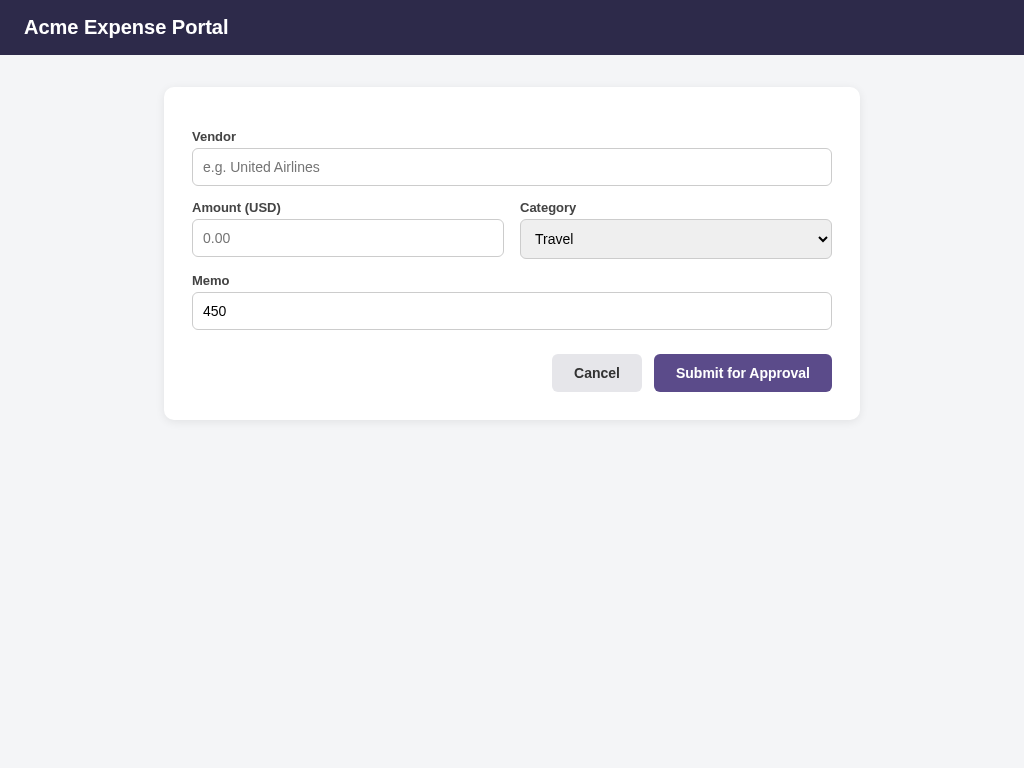

In [23]:
# Did it work? The form shows a green confirmation only if Submit was actually clicked.
final

**It didn't submit.** (In MOCK mode this is scripted to match what we see live; with a real
key, you'll see the same class of failure — sometimes worse.)

Look at the coordinates the model chose. They're not *random* — they're plausible. It knows a
vendor field is near the top, Submit is bottom-right. But "plausible" isn't "pixel-accurate,"
and a click that's 40px too high hits a label instead of the input, or empty canvas instead of
the button. **The loop is correct. The grounding is wrong.**

---
# Stage 3 — Diagnose: this is the *grounding problem*

Let's make the failure legible. We'll overlay where the model *clicked* against where the
targets *actually are*. Because we own the HTML, we can query the true pixel boxes.

In [24]:
# Ask the page for the true bounding boxes of the real targets.
def true_boxes(url):
    b = Browser(); b.start(url)
    async def _boxes():
        out = {}
        for name, sel in [("vendor","#vendor"),("amount","#amount"),
                          ("category","#category"),("submit","#submit")]:
            bb = await b.page.locator(sel).bounding_box()
            out[name] = bb
        return out
    boxes = asyncio.get_event_loop().run_until_complete(_boxes())
    b.close(); return boxes

TRUTH = true_boxes(URL)
for k,v in TRUTH.items():
    cx, cy = v["x"]+v["width"]/2, v["y"]+v["height"]/2
    print(f"{k:10s} center = ({cx:.0f}, {cy:.0f})")

127.0.0.1 - - [08/Jul/2026 05:13:29] "GET /expense_app.html HTTP/1.1" 200 -


vendor     center = (512, 167)
amount     center = (348, 238)
category   center = (676, 239)
submit     center = (743, 373)


127.0.0.1 - - [08/Jul/2026 05:13:34] "GET /expense_app.html HTTP/1.1" 200 -


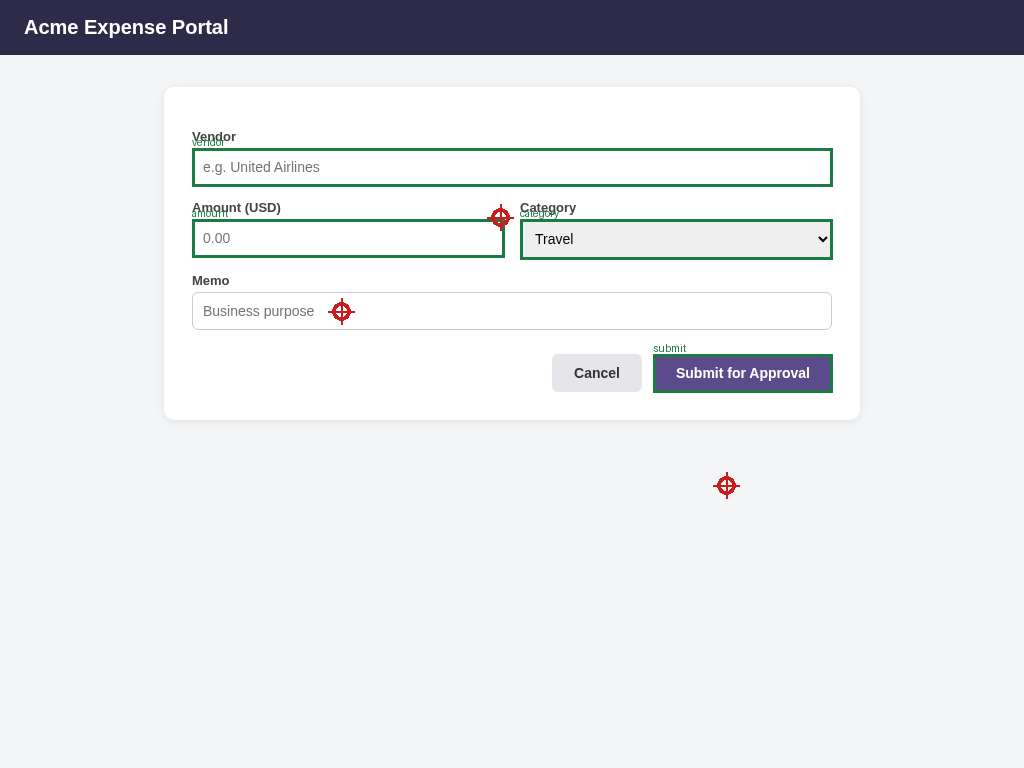

In [25]:
# Overlay the model's clicks (red) on the true target centers (green) over the clean screenshot.
from PIL import ImageDraw
b = Browser(); b.start(URL); base = b.screenshot(); b.close()
canvas = base.convert("RGB"); d = ImageDraw.Draw(canvas)

for name, v in TRUTH.items():
    cx, cy = v["x"]+v["width"]/2, v["y"]+v["height"]/2
    d.rectangle([v["x"],v["y"],v["x"]+v["width"],v["y"]+v["height"]], outline=(28,122,69), width=3)
    d.text((v["x"], v["y"]-12), name, fill=(28,122,69))

for act in history:
    if act.get("action")=="click":
        x,y = act["x"],act["y"]
        d.ellipse([x-9,y-9,x+9,y+9], outline=(200,30,30), width=4)
        d.line([x-13,y,x+13,y], fill=(200,30,30), width=2)
        d.line([x,y-13,x,y+13], fill=(200,30,30), width=2)
canvas

Green boxes = truth. Red crosshairs = where the model clicked. The gap between them **is** the
grounding problem, stated precisely:

> **Grounding** = mapping a *referring expression* ("the Submit button") to a *precise location
> in the observation* (pixel `(x, y)`), well enough to act on it.

A general vision model can *describe* a screen beautifully and still be tens of pixels off when
asked for a coordinate. Perception ≠ grounding. And in a multi-step loop, grounding errors
**compound**: a missed click leaves the screen in an unexpected state, the next decision is made
on that wrong state, and the trajectory diverges. This is why single good screenshots in a demo
tell you almost nothing about agent reliability.

### The whole field is a history of attacks on this one problem

Every era below is really an answer to *"how do I know where to click?"* — this is our through-line.

| Year | Move | Grounding strategy |
|------|------|--------------------|
| 2016 | OpenAI **Universe** | pixels→actions via RL. *Too early — no language.* |
| Oct 2023 | **GPT-4V-Act**, **Set-of-Mark** | Overlay numbered labels on elements; model picks a *number*, not a pixel. Sidesteps grounding. |
| Feb 2024 | Microsoft **UFO** | Vision + the OS **accessibility tree** for element locations. |
| Oct 2024 | **OmniParser** | A vision module parses the screen into elements *first*; feeds structured boxes to any VLM. |
| Oct 2024 | **Claude 3.5 Sonnet computer use** | Grounding trained **into** the model; a native tool with a fixed action space. |
| Jan 2025 | **Operator / CUA** | Same idea, OpenAI's model. |
| 2025 | **UI-TARS**, **UGround**, **Qwen-VL** | Open models trained end-to-end on GUI grounding. Screenshot-only. |

Set-of-Mark is worth trying yourself, because it's the cheapest fix and it *works*.

127.0.0.1 - - [08/Jul/2026 05:13:53] "GET /expense_app.html HTTP/1.1" 200 -


Now the model chooses from: {1: 'vendor', 2: 'amount', 3: 'category', 4: 'submit'}


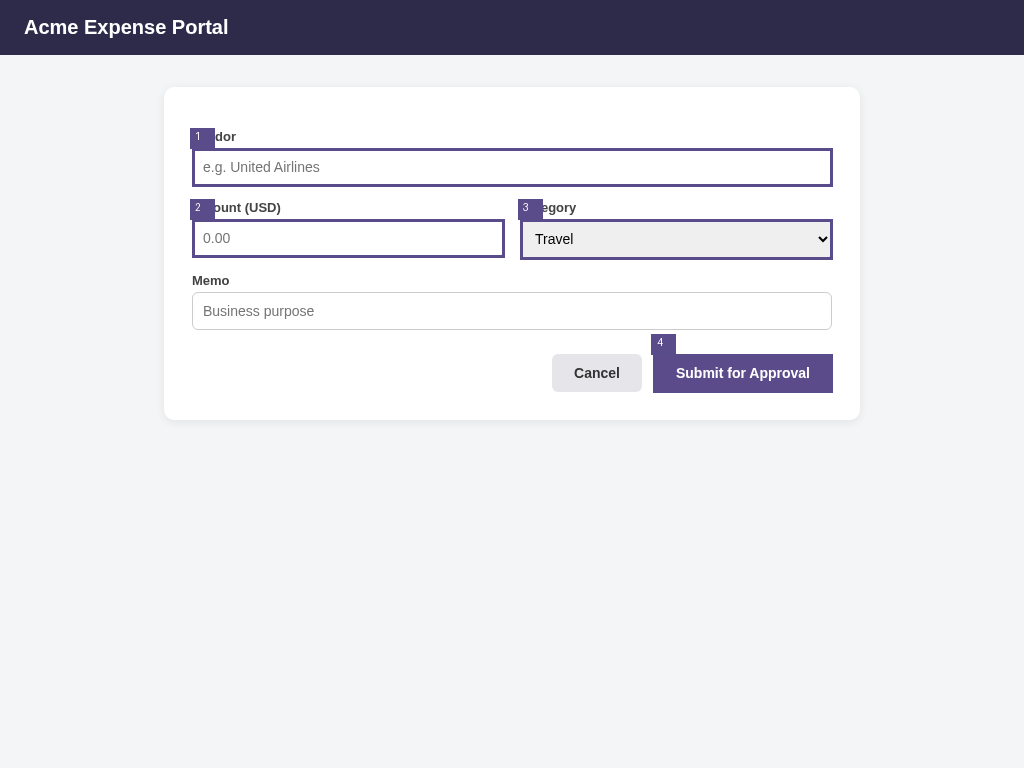

In [26]:
# Set-of-Mark: label the interactive elements with numbers, let the model choose a NUMBER.
# We reuse the true boxes as our "detector" (a real system uses OmniParser or the a11y tree).
def render_set_of_mark(url):
    b = Browser(); b.start(url); img = b.screenshot().convert("RGB"); b.close()
    d = ImageDraw.Draw(img); marks = {}
    for i,(name,v) in enumerate(TRUTH.items(), start=1):
        cx, cy = int(v["x"]+v["width"]/2), int(v["y"]+v["height"]/2)
        marks[i] = (cx, cy, name)
        d.rectangle([v["x"],v["y"],v["x"]+v["width"],v["y"]+v["height"]], outline=(90,75,138), width=3)
        d.rectangle([v["x"]-2, v["y"]-20, v["x"]+22, v["y"]], fill=(90,75,138))
        d.text((v["x"]+3, v["y"]-18), str(i), fill=(255,255,255))
    return img, marks

som_img, MARKS = render_set_of_mark(URL)
print("Now the model chooses from:", {i:m[2] for i,m in MARKS.items()})
som_img

With Set-of-Mark, the model's job collapses from *"estimate a pixel"* to *"pick 1, 2, 3, or 4."*
That's a multiple-choice question instead of a regression problem — far easier, far more reliable.
It's exactly why the earliest working browser agents used it. The catch: you need a detector to
find and label the elements in the first place. That detector *is* the grounding — you've just
moved it out of the language model. OmniParser is that detector as a standalone vision module;
the accessibility tree is that detector handed to you by the OS; and models like UI-TARS and
Claude's computer-use model **fold the detector back into the model** so you don't need one.

That last option is where the frontier went. Let's use it.

---
# Stage 4 — Swap in Claude's native computer-use tool

Same browser. Same task. We replace our hand-rolled `vlm_action` + JSON parser with Claude's
**`computer_20251124`** tool. Three things change, and each maps to a pain we just felt:

1. **Grounding is trained in.** Claude returns pixel coordinates for the image it was shown.
   No Set-of-Mark, no detector, no accessibility tree required.
2. **The action space is fixed and schema-less.** We don't invent a JSON format and pray the
   model follows it. The tool defines `screenshot`, `left_click`, `type`, `key`, `scroll`,
   `double_click`, `left_click_drag`, `zoom`, etc. Claude emits `tool_use` blocks; we execute
   them and return a `tool_result` (usually a fresh screenshot).
3. **The loop is a documented contract**, not our improvisation — the "agent loop": model
   requests an action → we run it → we return the result → repeat until it stops asking.

Current facts (verified against the live docs):
- Beta header **`computer-use-2025-11-24`** for Claude Opus 4.8 / Sonnet 5 / Opus 4.7 / 4.6 / Sonnet 4.6.
- Tool type **`computer_20251124`**; the older **`computer_20250124`** covers Sonnet 4.5 / Haiku 4.5.
- **`zoom`** action (set `enable_zoom: true`) lets Claude inspect small text at full resolution —
  a direct fix for the "target too small" grounding failure.
- **Place instruction text *before* the screenshot** in the content array — the docs note this
  improves click accuracy (describe the target before the image is processed).
- Default agent loop caps at ~10 iterations to prevent runaway API cost.

In [29]:
# The Anthropic SDK. In class, students with a real key run this live; others read the
# recorded trajectory in the next cell.
from google.colab import userdata

!pip install anthropic --quiet
import os, getpass, anthropic
ANTHROPIC_KEY = userdata.get("ANTHROPIC_API_KEY")
if not ANTHROPIC_KEY:
    try: ANTHROPIC_KEY = getpass.getpass("Anthropic API key (blank = read recorded run): ").strip()
    except Exception: ANTHROPIC_KEY = ""
LIVE_CLAUDE = bool(ANTHROPIC_KEY)
print("Claude stage:", "LIVE" if LIVE_CLAUDE else "recorded trajectory")

Claude stage: LIVE


In [30]:
# Map Claude's tool actions onto our Browser. This is the "execute" half of the agent loop:
# translate an abstract action request into a real operation, then hand back a screenshot.
def execute_claude_action(b, inp):
    action = inp.get("action")
    if action == "screenshot":
        pass  # we always return a fresh screenshot below
    elif action in ("left_click","right_click","middle_click","double_click"):
        x,y = inp["coordinate"]; b.click(x,y)
        if action == "double_click": b.click(x,y)
    elif action == "type":
        b.type_text(inp["text"])
    elif action == "key":
        # Claude sends e.g. "ctrl+s"; Playwright wants "Control+S"
        b.press(inp["text"].replace("ctrl","Control").replace("+"," +").replace(" ","").title())
    elif action == "scroll":
        amt = inp.get("scroll_amount",3) * 100
        b.scroll(amt if inp.get("scroll_direction")=="down" else -amt)
    elif action == "left_click_drag":
        pass  # omitted for brevity
    # zoom / wait / mouse_move: no-op or trivial in this browser setting
    return b.screenshot_b64()

print("Action executor ready.")

Action executor ready.


In [31]:
COMPUTER_TOOL = {
    "type": "computer_20251124",
    "name": "computer",
    "display_width_px": 1024,
    "display_height_px": 768,
    "display_number": 1,
    "enable_zoom": True,          # let Claude inspect small UI at full res
}
BETA = "computer-use-2025-11-24"
MODEL = "claude-opus-4-8"        # any computer-use-capable model

# The self-verification prompt straight from Anthropic's docs — it measurably reduces the
# "assume the click worked" failure, which is exactly the compounding error from Stage 3.
SYS_HINT = ('After each step, take a screenshot and carefully evaluate if you achieved the '
            'right outcome. Show your thinking. Only move on once a step is confirmed correct.')

def run_claude_agent(task, url, max_iters=10):
    b = Browser(); b.start(url)
    client = anthropic.Anthropic(api_key=ANTHROPIC_KEY)
    # NOTE: instruction text BEFORE the screenshot, per the docs' grounding tip.
    messages = [{"role":"user","content":[
        {"type":"text","text":task},
        {"type":"image","source":{"type":"base64","media_type":"image/png","data":b.screenshot_b64()}}]}]
    trace = []
    for _ in range(max_iters):
        resp = client.beta.messages.create(
            model=MODEL, max_tokens=1024, system=SYS_HINT,
            tools=[COMPUTER_TOOL], betas=[BETA], messages=messages)
        messages.append({"role":"assistant","content":resp.content})
        tool_results = []
        for block in resp.content:
            if block.type == "text":
                trace.append(("say", block.text))
            elif block.type == "tool_use":
                trace.append(("act", block.input))
                shot = execute_claude_action(b, block.input)
                tool_results.append({"type":"tool_result","tool_use_id":block.id,
                    "content":[{"type":"image","source":{"type":"base64",
                    "media_type":"image/png","data":shot}}]})
        if not tool_results:          # Claude stopped requesting tools -> task complete
            break
        messages.append({"role":"user","content":tool_results})
    final = b.screenshot(); b.close()
    return trace, final

if LIVE_CLAUDE:
    trace, claude_final = run_claude_agent(TASK, URL)
    for kind, payload in trace: print(kind, "::", payload)
else:
    print("No key — see recorded trajectory below.")

127.0.0.1 - - [08/Jul/2026 05:39:37] "GET /expense_app.html HTTP/1.1" 200 -


say :: I'll fill out the expense form. Let me start by clicking the Vendor field and entering the details.
act :: {'action': 'left_click', 'coordinate': [511, 167]}
say :: The Vendor field is focused. Let me type the vendor name.
act :: {'action': 'type', 'text': 'United Airlines'}
say :: Vendor is set. Now let me click the Amount field and enter 450.
act :: {'action': 'left_click', 'coordinate': [347, 238]}
act :: {'action': 'type', 'text': '450'}
say :: All fields are set correctly: Vendor is "United Airlines", Amount is 450, and Category is already "Travel" as required. Now I'll submit the expense.
act :: {'action': 'left_click', 'coordinate': [742, 373]}
say :: The expense has been submitted successfully. A green confirmation message appears at the bottom: "✓ Submitted: United Airlines — $450".

The expense was filed with:
- **Vendor:** United Airlines
- **Amount:** $450
- **Category:** Travel

The task is complete.


### Recorded trajectory (for anyone without a key)

A representative successful run of the loop above. Notice the shape: Claude *narrates its
plan*, requests a `screenshot`, then issues a `left_click` with coordinates, types, verifies
with another screenshot, and only then submits. The coordinates land — because grounding is in
the model — and it checks its own work between steps.

```
say :: I'll file this expense. First, let me see the form clearly.
act :: {'action': 'screenshot'}
say :: I can see the vendor field near the top. Clicking it.
act :: {'action': 'left_click', 'coordinate': [512, 167]}
act :: {'action': 'type', 'text': 'United Airlines'}
say :: Now the amount field, below and to the left.
act :: {'action': 'left_click', 'coordinate': [348, 238]}
act :: {'action': 'type', 'text': '450'}
say :: Category already defaults to Travel, which is correct — no change needed.
act :: {'action': 'screenshot'}
say :: Fields look correct: vendor and amount populated, category Travel. Clicking Submit.
act :: {'action': 'left_click', 'coordinate': [743, 373]}
act :: {'action': 'screenshot'}
say :: Confirmation banner shows "Submitted: United Airlines — $450". Task complete.
```

The contrast with Stage 2 is the entire lesson: **same loop, same task, same browser — the only
thing that changed is that grounding moved into the model and the action space became a
contract instead of a hope.**

---
# Stage 5 — Where the frontier actually is

You've now built both halves. Let's situate them against the real state of the art (mid-2026).

## OSWorld: the benchmark that keeps everyone honest

**OSWorld** (XLang Labs, April 2024) is 369 real desktop tasks on Ubuntu/Windows with
*execution-based* grading — it checks the final computer state, so there's no partial credit for
"almost." It became the field's yardstick because it's hard to game. The trajectory of the SOTA
is the story of this entire class:

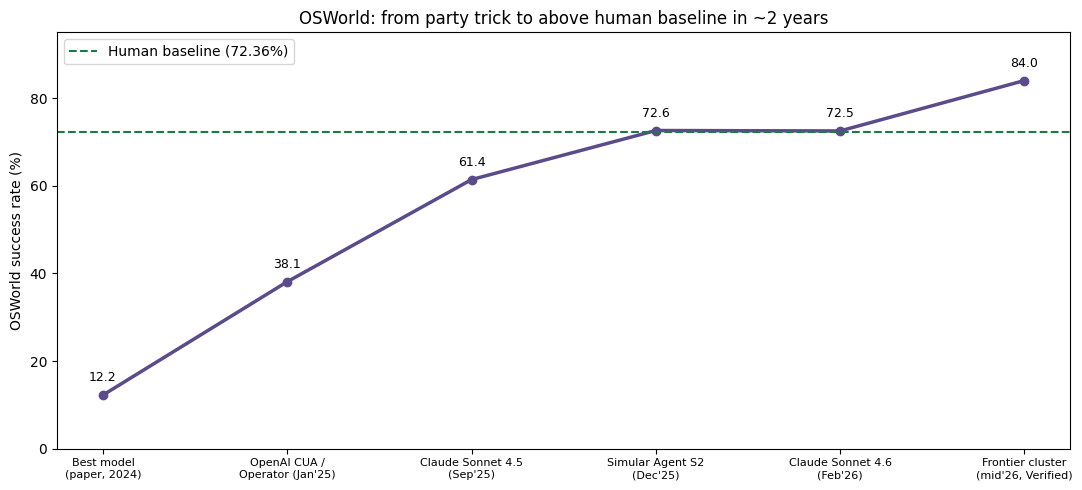

In [32]:
import matplotlib.pyplot as plt

# OSWorld success rate over time (triangulated from multiple public trackers; frontier numbers
# are OSWorld-Verified and cluster tightly as the benchmark nears saturation).
points = [
    ("Best model\n(paper, 2024)", 12.24),
    ("OpenAI CUA /\nOperator (Jan'25)", 38.1),
    ("Claude Sonnet 4.5\n(Sep'25)", 61.4),
    ("Simular Agent S2\n(Dec'25)", 72.6),
    ("Claude Sonnet 4.6\n(Feb'26)", 72.5),
    ("Frontier cluster\n(mid'26, Verified)", 84.0),
]
labels = [p[0] for p in points]; vals = [p[1] for p in points]
fig, ax = plt.subplots(figsize=(11,5))
ax.plot(range(len(vals)), vals, marker="o", linewidth=2.5, color="#5b4b8a")
ax.axhline(72.36, ls="--", color="#1c7a45", label="Human baseline (72.36%)")
for i,v in enumerate(vals): ax.annotate(f"{v:.1f}", (i,v), textcoords="offset points", xytext=(0,10), ha="center", fontsize=9)
ax.set_xticks(range(len(labels))); ax.set_xticklabels(labels, fontsize=8)
ax.set_ylabel("OSWorld success rate (%)"); ax.set_ylim(0,95)
ax.set_title("OSWorld: from party trick to above human baseline in ~2 years")
ax.legend(); plt.tight_layout(); plt.show()